# Angeliki Andreadi, Keenan Hardy

## CCBD Project 6 — Cloud Bill Estimator: Analysis
### **Variant 6**: Cost ("cloud bill") estimator for S3 object storage.
### This notebook reads results.csv from bench.py, compares cost and query time, and helps decide which storage layout is best.

In [ ]:
# Import the libraries for tables and plots, then load the benchmark results.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
df = pd.read_csv('results.csv')

## Baseline
Start with the raw CSV results. This gives us the reference point for all later comparisons.

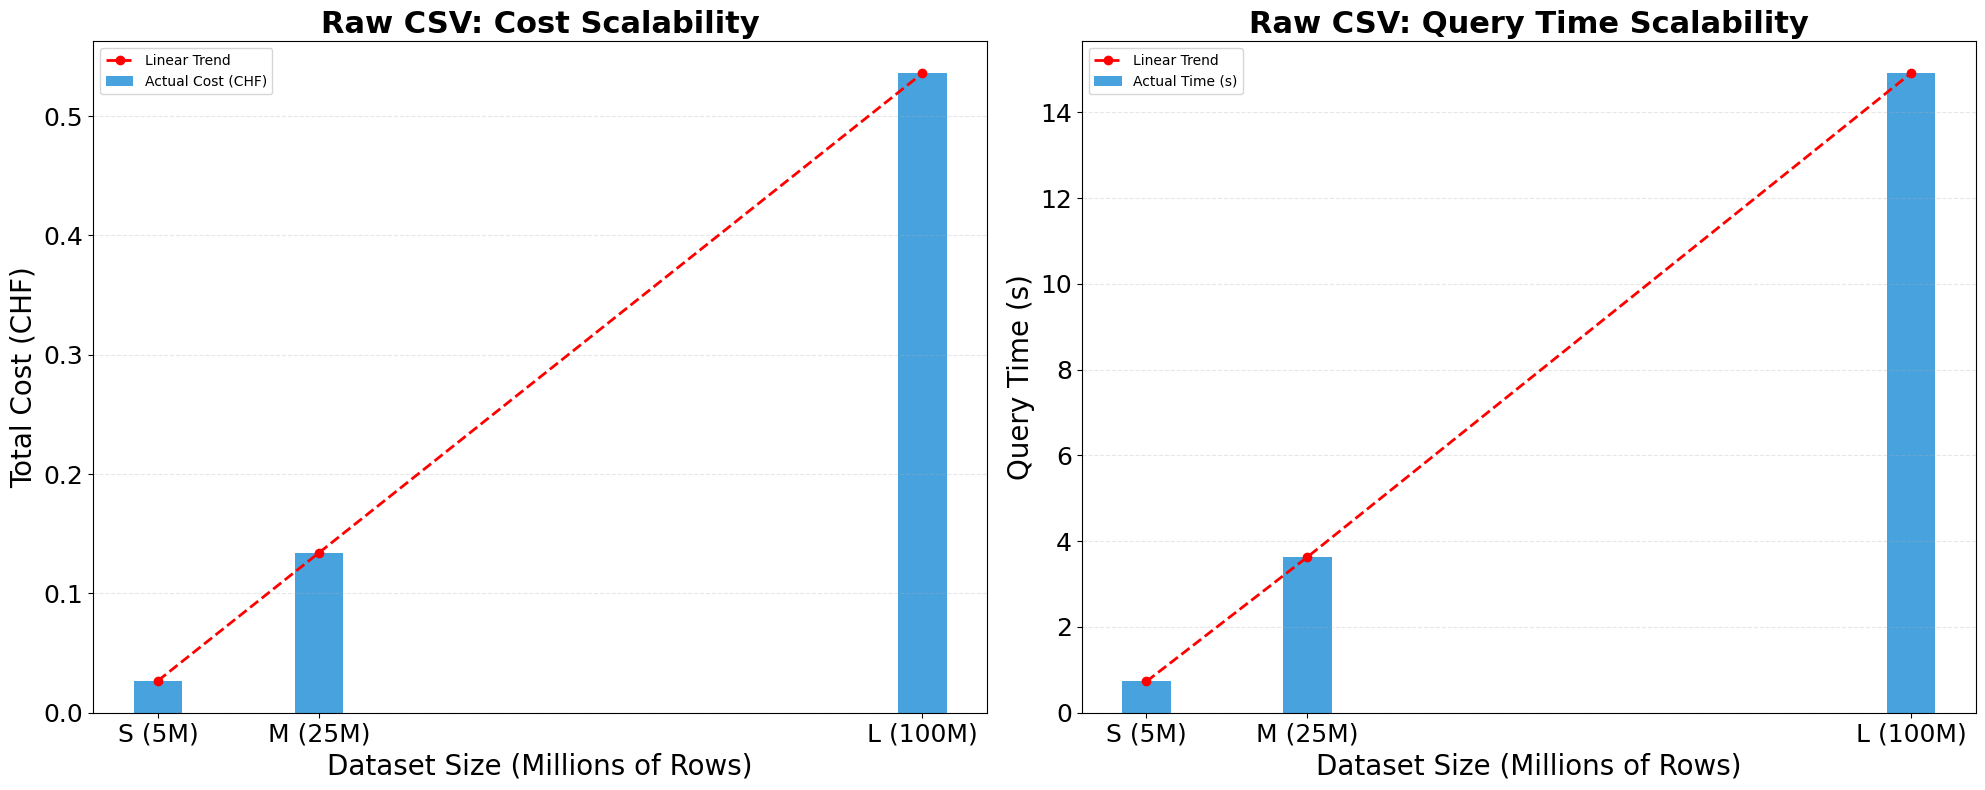

In [25]:
row_counts = np.array([5, 25, 100])
labels = ['S (5M)', 'M (25M)', 'L (100M)']
width = 6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

raw_metrics = df[df['variant'] == 'raw'].set_index('label').reindex(['S', 'M', 'L'])

ax1.bar(row_counts, raw_metrics['total_chf'], width, color='#3498db', alpha=0.9, label='Actual Cost (CHF)')
ax1.plot(row_counts, raw_metrics['total_chf'], marker='o', color='red', linestyle='--', linewidth=2, label='Linear Trend')

ax1.set_title('Raw CSV: Cost Scalability', fontsize=22, fontweight='bold')
ax1.set_ylabel('Total Cost (CHF)', fontsize=20)
ax1.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax1.tick_params(axis='both', which='major', labelsize=18)

ax2.bar(row_counts, raw_metrics['query_time_s'], width, color='#3498db', alpha=0.9, label='Actual Time (s)')
ax2.plot(row_counts, raw_metrics['query_time_s'], marker='o', color='red', linestyle='--', linewidth=2, label='Linear Trend')

ax2.set_title('Raw CSV: Query Time Scalability', fontsize=22, fontweight='bold')
ax2.set_ylabel('Query Time (s)', fontsize=20)
ax2.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

ax2.tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.show()

In [11]:
# Build one readable name per variant, including compression when it exists.
df['full_variant'] = df.apply(
    lambda x: f"{x['variant']}_{x['compression']}" if pd.notnull(x['compression']) and x['compression'] != '' 
    else x['variant'], axis=1
)

# A lower efficiency index means the option is both cheaper and faster.
df['efficiency_index'] = df['total_chf'] * df['query_time_s'] 

# Compare every option against the raw CSV baseline for the same dataset size.
baselines = df[df['variant'] == 'raw'].set_index('label')['efficiency_index'].to_dict()

df['baseline_efficiency'] = df['label'].map(baselines)
df['improvement_factor'] = df['baseline_efficiency'] / df['efficiency_index']

summary = df.sort_values(['label', 'improvement_factor'], ascending=[True, False])
cols = ['label', 'full_variant', 'total_chf', 'query_time_s', 'efficiency_index', 'improvement_factor']

In [12]:
print(f"\nBaseline Metrics: Raw CSV")
print("-" * 90)

size_subset = summary[summary['full_variant'] == "raw"][cols]

print(size_subset.to_string(
    index=False,
    col_space=[8, 12, 12, 12, 15, 12],
    justify='left',
    formatters={
        # Format numbers so the printed table is easier to read.
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.1f}'.format
    }
))
print("-" * 90)


Baseline Metrics: Raw CSV
------------------------------------------------------------------------------------------
label    full_variant total_chf    query_time_s efficiency_index improvement_factor
L        raw          0.535903     14.910       7.990314         1.0               
M        raw          0.133992     3.630        0.486391         1.0               
S        raw          0.026817     0.729        0.019550         1.0               
------------------------------------------------------------------------------------------


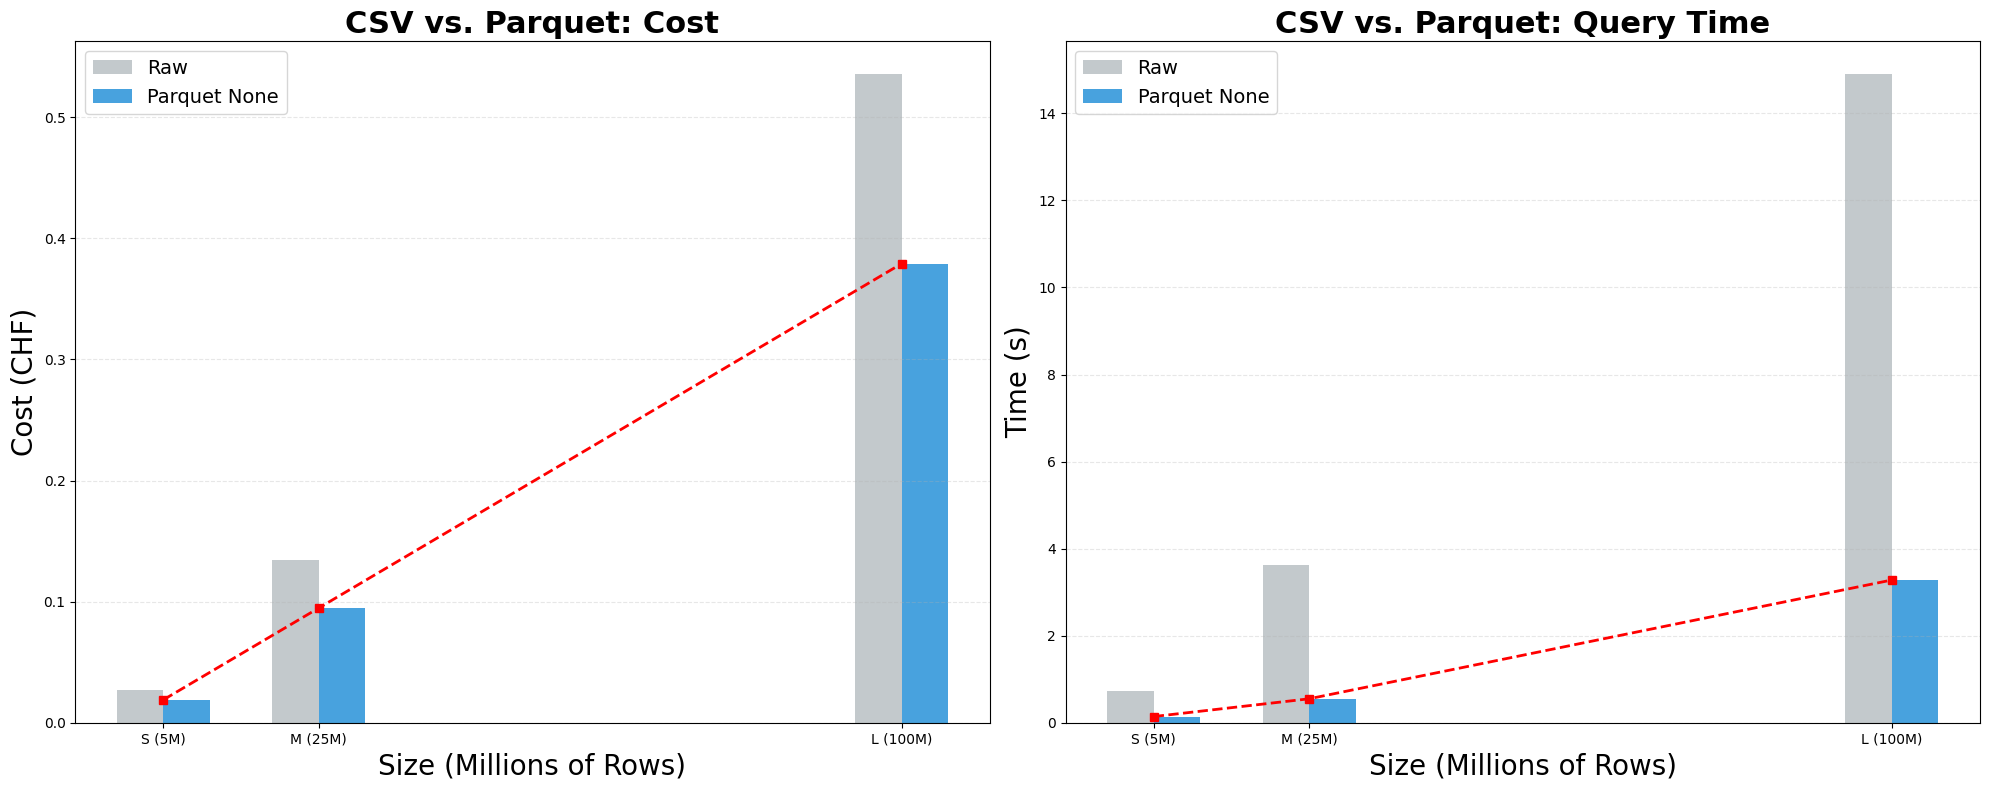

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Compare the raw CSV baseline with a single uncompressed Parquet file.
row_counts = np.array([5, 25, 100])
labels = ['S (5M)', 'M (25M)', 'L (100M)']
variants = ['raw', 'parquet_none']
colors = ['#bdc3c7', '#3498db']  # grey for raw, blue for Parquet
width = 6 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left plot: total estimated cost.
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 0.5) * width
    ax1.bar(row_counts + offset, v_data['total_chf'], width, 
            label=variant.replace('_', ' ').title(), color=colors[i], alpha=0.9)

# Draw a simple line through the Parquet bars to see how cost scales.
par_cost_trend = df[df['full_variant'] == 'parquet_none'].set_index('label').reindex(['S', 'M', 'L'])['total_chf']
ax1.plot(row_counts, par_cost_trend, color='red', linestyle='--', marker='s', linewidth=2)

ax1.set_title('CSV vs. Parquet: Cost', fontsize=22, fontweight='bold')
ax1.set_ylabel('Cost (CHF)', fontsize=20)
ax1.set_xlabel('Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend(fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.3)


# Right plot: query time for the same variants.
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 0.5) * width
    ax2.bar(row_counts + offset, v_data['query_time_s'], width, 
            label=variant.replace('_', ' ').title(), color=colors[i], alpha=0.9)

# Draw a simple line through the Parquet query times.
par_time_trend = df[df['full_variant'] == 'parquet_none'].set_index('label').reindex(['S', 'M', 'L'])['query_time_s']
ax2.plot(row_counts, par_time_trend, color='red', linestyle='--', marker='s', linewidth=2)

ax2.set_title('CSV vs. Parquet: Query Time', fontsize=22, fontweight='bold')
ax2.set_ylabel('Time (s)', fontsize=20)
ax2.set_xlabel('Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend(fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
print(f"\nBaseline Metrics: Raw CSV vs Uncompressed Parquet")
print("-" * 95)

mask = (summary['full_variant'] == "raw") | (summary['full_variant'] == "parquet_none")
size_subset = summary[mask][cols]

print(size_subset.to_string(
    index=False,
    col_space=[8, 22, 12, 12, 15, 12], # leave room for longer variant names
    justify='left',
    formatters={
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.2f}'.format
    }
))
print("-" * 95)


Baseline Metrics: Raw CSV vs Uncompressed Parquet
-----------------------------------------------------------------------------------------------
label    full_variant           total_chf    query_time_s efficiency_index improvement_factor
L        parquet_none           0.379054     3.279        1.242918         6.43              
L                 raw           0.535903     14.910       7.990314         1.00              
M        parquet_none           0.094780     0.550        0.052129         9.33              
M                 raw           0.133992     3.630        0.486391         1.00              
S        parquet_none           0.018974     0.142        0.002694         7.26              
S                 raw           0.026817     0.729        0.019550         1.00              
-----------------------------------------------------------------------------------------------


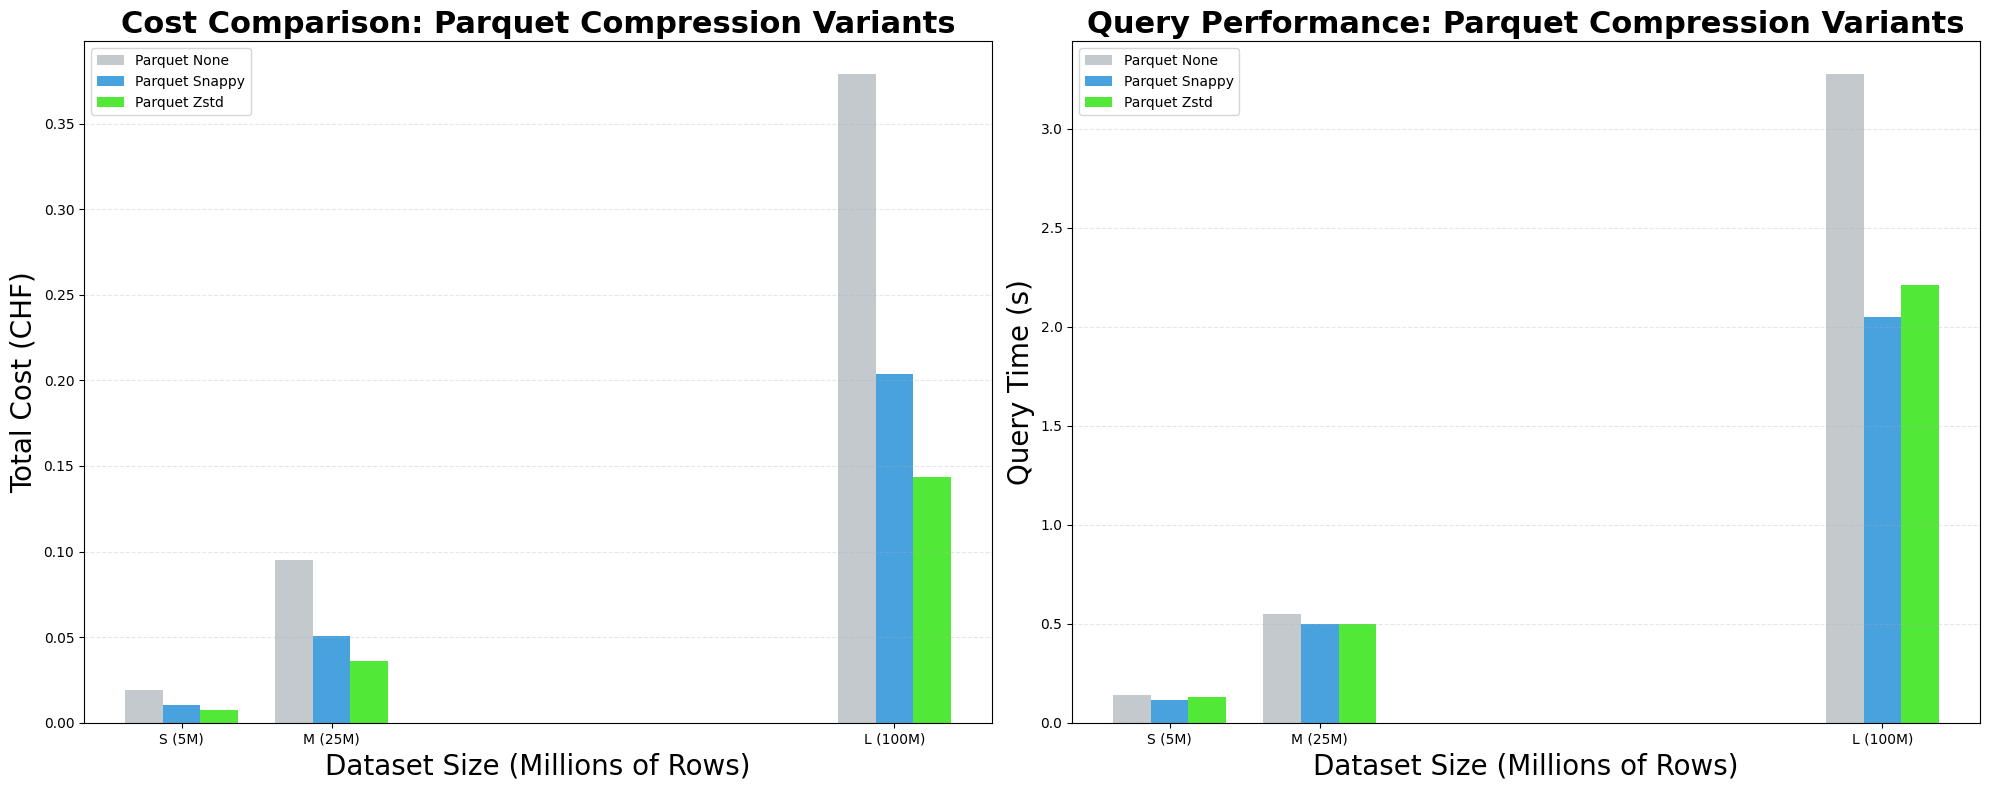

In [10]:
variants = ['parquet_none', 'parquet_snappy', 'parquet_zstd']

# Compare Parquet compression choices: none, Snappy, and ZSTD.
left_colors = ['#bdc3c7', '#3498db', "#3fe622c6"]  # one color per compression option
right_colors = ['#bdc3c7', '#3498db', "#3fe622c6"] # same colors on the time chart
width = 5 

# Create side-by-side plots so cost and speed can be compared together.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left plot: total cost for each compression option.
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width # center the middle bar on the dataset-size tick
    ax1.bar(row_counts + offset, v_data['total_chf'], width, 
            label=variant.replace('_', ' ').title(), color=left_colors[i], alpha=0.9)

# Store the ZSTD cost series because it is the strongest compression candidate.
zstd_s_trend = df[df['full_variant'] == 'parquet_zstd'].set_index('label').reindex(['S', 'M', 'L'])['total_chf']

ax1.set_title('Parquet Compression Variants: Cost Scalability', fontsize=22, fontweight='bold')
ax1.set_ylabel('Total Cost (CHF)', fontsize=20)
ax1.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Right plot: query time for the same compression options.
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width
    ax2.bar(row_counts + offset, v_data['query_time_s'], width, 
            label=variant.replace('_', ' ').title(), color=right_colors[i], alpha=0.9)

# Store the ZSTD time series for the same reason as above.
zstd_t_trend = df[df['full_variant'] == 'parquet_zstd'].set_index('label').reindex(['S', 'M', 'L'])['query_time_s']

ax2.set_title('Parquet Compression Variants: Query Time Scalability', fontsize=22, fontweight='bold')
ax2.set_ylabel('Query Time (s)', fontsize=20)
ax2.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print(f"\nBaseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd")
print("-" * 95)

mask = (summary['full_variant'] == "parquet_none") | (summary['full_variant'] == "parquet_snappy")| (summary['full_variant'] == "parquet_zstd")
size_subset = summary[mask][cols]

# Print the compression comparison in a compact table.
print(size_subset.to_string(
    index=False,
    col_space=[8, 22, 12, 12, 15, 12], # leave room for longer variant names
    justify='left',
    formatters={
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.2f}'.format
    }
))

print("-" * 95)


Baseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd
-----------------------------------------------------------------------------------------------
label    full_variant           total_chf    query_time_s efficiency_index improvement_factor
L          parquet_zstd         0.143375     2.214        0.317432         25.17             
L        parquet_snappy         0.203565     2.048        0.416901         19.17             
L          parquet_none         0.379054     3.279        1.242918         6.43              
M          parquet_zstd         0.035861     0.497        0.017823         27.29             
M        parquet_snappy         0.050908     0.501        0.025505         19.07             
M          parquet_none         0.094780     0.550        0.052129         9.33              
S          parquet_zstd         0.007190     0.128        0.000920         21.24             
S        parquet_snappy         0.010199     0.116        0.001183         16.

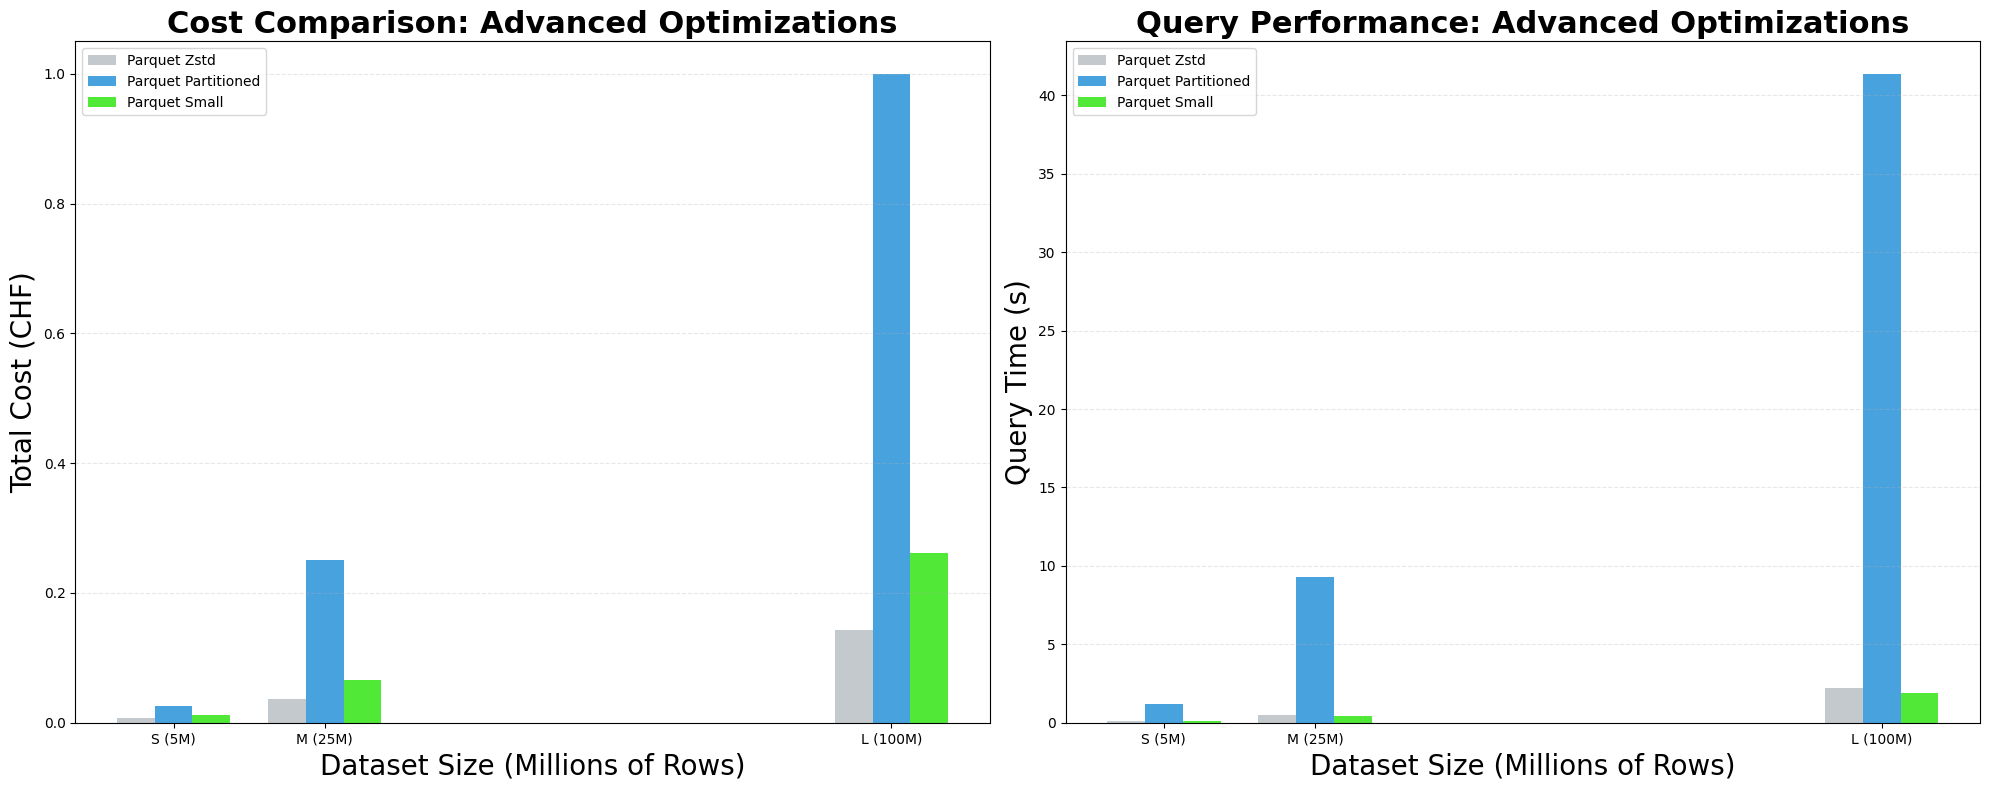

In [8]:
variants = ['parquet_zstd', 'parquet_partitioned', 'parquet_small']

left_colors = ['#bdc3c7', '#3498db', "#3fe622c6"]  # one color per layout option
right_colors = ['#bdc3c7', '#3498db', "#3fe622c6"] # same colors on the time chart
width = 5 

# Compare the best compressed Parquet file with small-file and partitioned layouts.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left plot: total cost for each layout.
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width
    ax1.bar(row_counts + offset, v_data['total_chf'], width, 
            label=variant.replace('_', ' ').title(), color=left_colors[i], alpha=0.9)

ax1.set_title('Parquet (Zstd) vs Partitionning : Cost Scalability', fontsize=22, fontweight='bold')
ax1.set_ylabel('Total Cost (CHF)', fontsize=20)
ax1.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax1.set_xticks(row_counts)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Right plot: query time for each layout.
for i, variant in enumerate(variants):
    v_data = df[df['full_variant'] == variant].set_index('label').reindex(['S', 'M', 'L'])
    offset = (i - 1) * width
    ax2.bar(row_counts + offset, v_data['query_time_s'], width, 
            label=variant.replace('_', ' ').title(), color=right_colors[i], alpha=0.9)

ax2.set_title('Parquet (Zstd) vs Partitionning : Query Time Scalability', fontsize=22, fontweight='bold')
ax2.set_ylabel('Query Time (s)', fontsize=20)
ax2.set_xlabel('Dataset Size (Millions of Rows)', fontsize=20)
ax2.set_xticks(row_counts)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
print(f"\nBaseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd")
print("-" * 95)

mask = (summary['full_variant'] == "parquet_zstd") | (summary['full_variant'] == "parquet_small")| (summary['full_variant'] == "parquet_partitioned")
size_subset = summary[mask][cols]

print(size_subset.to_string(
    index=False,
    col_space=[8, 22, 12, 12, 15, 12], # leave room for longer variant names
    justify='left',
    formatters={
        'total_chf': '{:<10.6f}'.format,         
        'query_time_s': '{:<10.3f}'.format,
        'efficiency_index': '{:<15.6f}'.format,
        'improvement_factor': '{:<15.2f}'.format 
    }
))

print("-" * 95)


Baseline Metrics: Uncompressed Parquet vs Parquet Snappy vs Parquet Zstd
-----------------------------------------------------------------------------------------------
label    full_variant           total_chf    query_time_s efficiency_index improvement_factor
L               parquet_zstd    0.143375     2.214        0.317432         25.17             
L              parquet_small    0.260996     1.927        0.502939         15.89             
L        parquet_partitioned    1.000281     41.378       41.389627        0.19              
M               parquet_zstd    0.035861     0.497        0.017823         27.29             
M              parquet_small    0.065255     0.452        0.029495         16.49             
M        parquet_partitioned    0.251089     9.288        2.332115         0.21              
S               parquet_zstd    0.007190     0.128        0.000920         21.24             
S              parquet_small    0.012652     0.105        0.001328         14.